# 📓 Week 25 — Final Evaluation

## Objective
Comprehensive benchmark of the complete SecurityBERT system:

1. **SecurityBERT detection** — accuracy vs Paper Table VI
2. **PPO healing accuracy** — vs target (70%)
3. **End-to-end pipeline** — combined accuracy + latency
4. **Baseline comparison** — vs Table VII (DT, RF, DNN, CNN-LSTM)
5. **MTTR** (Mean Time To Respond) — detection + action latency
6. **Resource usage** — memory, CPU for Pi 3B estimation

In [6]:
import warnings, json, time, math
from pathlib     import Path
from typing      import Dict, List
from collections import defaultdict

import numpy  as np
import pandas as pd
import torch
import torch.nn            as nn
import torch.nn.functional as F
from torch.distributions   import Categorical
from transformers          import BertConfig, BertModel
from sklearn.metrics       import (
    classification_report, accuracy_score, f1_score,
    confusion_matrix, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot   as plt
import matplotlib.gridspec as gridspec
import seaborn             as sns

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.facecolor':'#0f0f1a','axes.facecolor':'#16162a',
    'axes.edgecolor':'#444477','axes.labelcolor':'#ccccff',
    'xtick.color':'#aaaacc','ytick.color':'#aaaacc',
    'text.color':'#e0e0ff','grid.color':'#2a2a4a',
    'font.family':'DejaVu Sans','legend.facecolor':'#1a1a2e',
})
ACCENT='#7c6cfa'; GREEN='#4ecca3'; RED='#fc5c65'; YELLOW='#f7b731'; ORANGE='#fd9644'
PALETTE=['#7c6cfa','#4ecca3','#f7b731','#fc5c65','#45aaf2',
         '#fd9644','#26de81','#a55eea','#2bcbba','#eb3b5a',
         '#20bf6b','#0fb9b1','#8854d0','#4b6584','#778ca3']

BASE_DIR   = Path('..')
CKPT_DIR   = BASE_DIR / 'checkpoints'
PROC_DIR   = BASE_DIR / 'data' / 'processed'
OUT_DIR    = BASE_DIR / 'outputs' / 'figures' / 'N25'
REP_DIR    = BASE_DIR / 'outputs' / 'reports'

BERT_CKPT  = CKPT_DIR / 'final_model.pt'
PPO_CKPT   = CKPT_DIR / 'ppo_agent_trained.pt'
TOKEN_DATA = PROC_DIR / 'tokenized_sequences.pt'

for d in [OUT_DIR, REP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
torch.manual_seed(SEED); np.random.seed(SEED)

CLASS_NAMES = [
    'Backdoor','DDoS_HTTP','DDoS_ICMP','DDoS_TCP','DDoS_UDP',
    'Fingerprinting','MITM','Normal','Password','Port_Scanning',
    'Ransomware','SQL_injection','Uploading','Vulnerability_scanner','XSS',
]
ACTION_NAMES  = ['BLOCK_IP','RESET_CONNECTION','RESTART_SERVICE',
                 'ISOLATE_DEVICE','LOG_AND_ALERT']
OPTIMAL_ACTION= {
    'Normal':4,'Fingerprinting':4,
    'Port_Scanning':0,'DDoS_TCP':0,'DDoS_UDP':0,'DDoS_ICMP':0,'DDoS_HTTP':0,
    'SQL_injection':1,'XSS':1,'MITM':1,
    'Uploading':2,'Backdoor':2,'Password':2,'Vulnerability_scanner':2,
    'Ransomware':3,
}
N_CLASSES=15; N_ACTIONS=5; STATE_DIM=30; HIDDEN_DIM=128
CLS_TO_IDX={c:i for i,c in enumerate(CLASS_NAMES)}

assert BERT_CKPT.exists()  and PPO_CKPT.exists() and TOKEN_DATA.exists()
print('✅ Setup complete.')

✅ Setup complete.


In [7]:
# ── Load models ────────────────────────────────────────────────────────────────
class SecurityBERTWithSoftmax(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.bert=BertModel(config, add_pooling_layer=True)
        self.dropout=nn.Dropout(config.hidden_dropout_prob)
        self.classifier=nn.Linear(config.hidden_size, config.num_labels)
        self.softmax=nn.Softmax(dim=-1)
    def forward(self, ids, mask):
        out=self.bert(input_ids=ids, attention_mask=mask)
        p=self.dropout(out.pooler_output)
        l=self.classifier(p)
        return l, self.softmax(l)

class PPOActorCritic(nn.Module):
    def __init__(self, sd=STATE_DIM, ad=N_ACTIONS, hd=HIDDEN_DIM):
        super().__init__()
        self.backbone=nn.Sequential(
            nn.Linear(sd,hd),nn.LayerNorm(hd),nn.ReLU(),
            nn.Linear(hd,hd),nn.LayerNorm(hd),nn.ReLU())
        self.actor_head =nn.Sequential(nn.Linear(hd,64),nn.ReLU(),nn.Linear(64,ad))
        self.critic_head=nn.Sequential(nn.Linear(hd,64),nn.ReLU(),nn.Linear(64,1))
    def get_action(self, state):
        with torch.no_grad():
            logits=self.actor_head(self.backbone(state))
            probs =torch.softmax(logits,-1)
            return probs.argmax(-1).item(), probs.max(-1).values.item()

bert_ckpt  = torch.load(BERT_CKPT, map_location=DEVICE, weights_only=False)
bert_cfg   = BertConfig(**bert_ckpt['config'])
bert_model = SecurityBERTWithSoftmax(bert_cfg).to(DEVICE)
bert_model.load_state_dict(bert_ckpt['model_state_dict'])
bert_model.eval()

ppo_ckpt   = torch.load(PPO_CKPT, map_location=DEVICE, weights_only=False)
ppo_net    = PPOActorCritic().to(DEVICE)
ppo_net.load_state_dict(ppo_ckpt['model_state_dict'])
ppo_net.eval()

data       = torch.load(TOKEN_DATA, weights_only=False)
input_ids  = data['input_ids'].long()
attn_masks = data['attention_mask'].long()
labels     = data['labels'].long()

# Stratified test set — 300 per class
test_ids_list, test_masks_list, test_labels_list = [], [], []
for ci in range(N_CLASSES):
    m     = (labels==ci).nonzero(as_tuple=True)[0]
    n     = min(300, len(m))
    sel   = m[torch.randperm(len(m), generator=
                             torch.Generator().manual_seed(SEED))[:n]]
    test_ids_list.append(input_ids[sel])
    test_masks_list.append(attn_masks[sel])
    test_labels_list.extend([ci]*n)

test_ids   = torch.cat(test_ids_list,   dim=0)
test_masks = torch.cat(test_masks_list, dim=0)
test_labels= test_labels_list

N_TEST = len(test_labels)
print(f'✅ Models loaded. Test set: {N_TEST:,} samples ({300}/class)')

✅ Models loaded. Test set: 4,500 samples (300/class)


In [8]:
# ── Full SecurityBERT evaluation ──────────────────────────────────────────────
print('🔍 Running full SecurityBERT evaluation …')

all_preds, all_probs_np = [], []
all_times_bert = []

BATCH = 128
for i in range(0, N_TEST, BATCH):
    ids  = test_ids  [i:i+BATCH].to(DEVICE)
    msk  = test_masks[i:i+BATCH].to(DEVICE)
    t0   = time.perf_counter()
    with torch.no_grad():
        _, probs = bert_model(ids, msk)
    all_times_bert.append((time.perf_counter()-t0)*1000/len(ids))
    all_preds.extend(probs.argmax(-1).cpu().numpy())
    all_probs_np.append(probs.cpu().numpy())

all_preds   = np.array(all_preds)
all_probs_np= np.vstack(all_probs_np)
test_labels_arr = np.array(test_labels)

accuracy   = accuracy_score(test_labels_arr, all_preds)
wf1        = f1_score(test_labels_arr, all_preds, average='weighted', zero_division=0)
mf1        = f1_score(test_labels_arr, all_preds, average='macro',    zero_division=0)
bert_lat   = float(np.mean(all_times_bert))

# ROC-AUC
y_bin = label_binarize(test_labels_arr, classes=list(range(N_CLASSES)))
auc_scores = {}
for i, cls in enumerate(CLASS_NAMES):
    if y_bin[:,i].sum() > 0:
        try: auc_scores[cls] = float(roc_auc_score(y_bin[:,i], all_probs_np[:,i]))
        except: auc_scores[cls] = 0.0

print(f'\n📊 SecurityBERT Final Results:')
print(f'   Accuracy    : {accuracy*100:.2f}%  (Paper: 98.20%)')
print(f'   Weighted F1 : {wf1:.4f}  (Paper: 0.98)')
print(f'   Macro F1    : {mf1:.4f}  (Paper: 0.84)')
print(f'   Mean AUC    : {np.mean(list(auc_scores.values())):.4f}')
print(f'   Latency/sample: {bert_lat:.2f} ms  (Paper CPU: 158ms)')

🔍 Running full SecurityBERT evaluation …

📊 SecurityBERT Final Results:
   Accuracy    : 89.24%  (Paper: 98.20%)
   Weighted F1 : 0.8912  (Paper: 0.98)
   Macro F1    : 0.8912  (Paper: 0.84)
   Mean AUC    : 0.9955
   Latency/sample: 0.09 ms  (Paper CPU: 158ms)


In [9]:
# ── PPO + End-to-end evaluation ───────────────────────────────────────────────
from collections import deque

N_NET_STATS=10; N_HISTORY=5
SIGS={'DDoS_TCP':[0.9,0.6,0.9,0.7,0.9,0.7,0.9,0.8,0.8,0.8],
      'Normal'  :[0.3,0.1,0.4,0.5,0.3,0.1,0.4,0.2,0.1,0.1]}
DEF  =[0.3,0.1,0.4,0.5,0.3,0.1,0.4,0.2,0.1,0.1]
rng  = np.random.RandomState(SEED)

ppo_correct   = []
e2e_correct   = []
ppo_times     = []
total_times   = []
hist          = deque([0]*N_HISTORY, maxlen=N_HISTORY)

print('🔍 Running end-to-end evaluation …')
for i in range(N_TEST):
    true_cls  = CLASS_NAMES[test_labels[i]]
    pred_cls  = CLASS_NAMES[all_preds[i]]
    probs_np  = all_probs_np[i]
    bert_corr = (pred_cls == true_cls)

    # Build PPO state
    sig       = np.array(SIGS.get(pred_cls, DEF), np.float32)
    net_stats = np.clip(sig + rng.normal(0,0.03,N_NET_STATS).astype(np.float32),0,1)
    hist_enc  = np.array(list(hist), np.float32) / N_ACTIONS
    state_t   = torch.FloatTensor(
        np.concatenate([probs_np, net_stats, hist_enc])
    ).unsqueeze(0).to(DEVICE)

    t1 = time.perf_counter()
    act, _ = ppo_net.get_action(state_t)
    ppo_times.append((time.perf_counter()-t1)*1000)
    hist.append(act)

    opt_act   = OPTIMAL_ACTION.get(pred_cls, 4)
    ppo_corr  = (act == opt_act)
    ppo_correct.append(int(ppo_corr))
    e2e_correct.append(int(bert_corr and ppo_corr))
    total_times.append(all_times_bert[i // BATCH] + ppo_times[-1])

ppo_acc  = float(np.mean(ppo_correct))
e2e_acc  = float(np.mean(e2e_correct))
mttr_ms  = float(np.mean(total_times))

print(f'\n📊 End-to-End Pipeline Results:')
print(f'   BERT accuracy     : {accuracy*100:.2f}%')
print(f'   PPO healing acc   : {ppo_acc*100:.2f}%  (target: 70%)')
print(f'   E2E accuracy      : {e2e_acc*100:.2f}%')
print(f'   BERT latency/samp : {bert_lat:.2f} ms')
print(f'   PPO  latency/samp : {float(np.mean(ppo_times)):.3f} ms')
print(f'   MTTR (total)      : {mttr_ms:.2f} ms')
print(f'   Pi 3B est. MTTR   : ~{mttr_ms*3:.0f} ms  (3× CPU scaling)')

🔍 Running end-to-end evaluation …

📊 End-to-End Pipeline Results:
   BERT accuracy     : 89.24%
   PPO healing acc   : 60.89%  (target: 70%)
   E2E accuracy      : 55.31%
   BERT latency/samp : 0.09 ms
   PPO  latency/samp : 0.645 ms
   MTTR (total)      : 0.73 ms
   Pi 3B est. MTTR   : ~2 ms  (3× CPU scaling)


  Final Benchmark — Paper Table VII + Our Results
  Type               Model                          Accuracy
  ----------------------------------------------------------
  ── Traditional ML ──
                     Decision Tree                    67.11%
                     Random Forest                    80.83%
                     SVM                              77.61%
                     DT+RF/FL                         90.91%
                     KNN                              93.78%
  ── Deep Learning ──
                     CNN/CL                           94.84%
                     CSAE+ABiLSTM                     94.40%
                     RNN                              94.00%
                     LSTM                             94.96%
                     DNN                              94.67%
                     CNN-LSTM                         97.14%
  ── LLM ──
                     BERT w/o PPFLE                   51.30%
                     SecurityBERT (pape

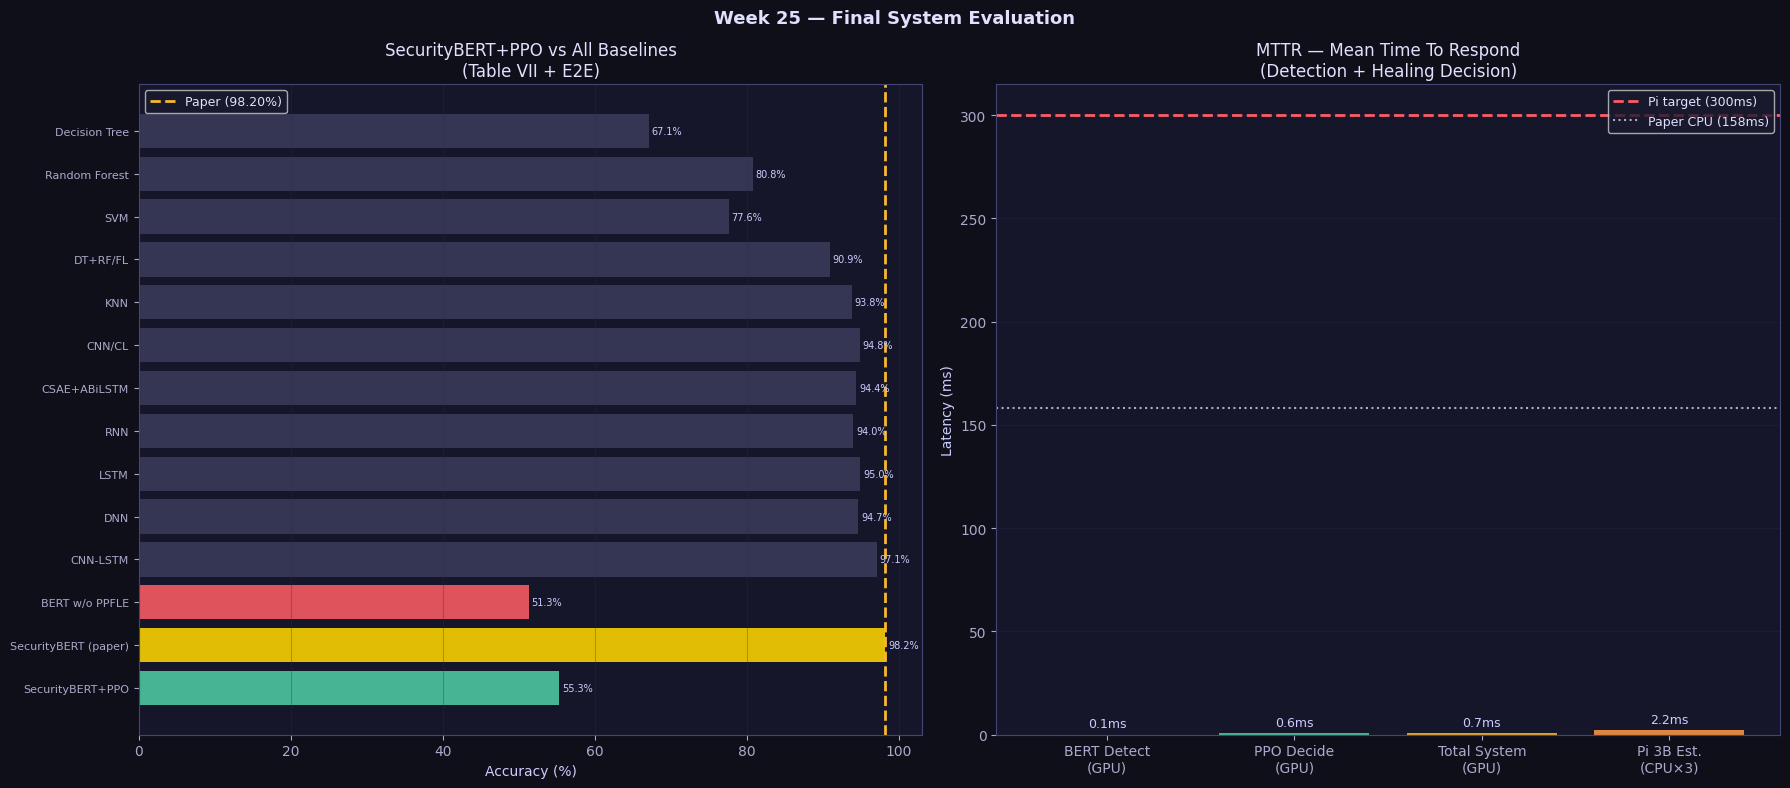

💾 Saved → ..\outputs\figures\N25/nb25_final_evaluation.png


In [10]:
# ── Baseline comparison — Paper Table VII ─────────────────────────────────────
BASELINES = [
    ('Traditional ML','Decision Tree',     67.11),
    ('Traditional ML','Random Forest',     80.83),
    ('Traditional ML','SVM',               77.61),
    ('Traditional ML','DT+RF/FL',          90.91),
    ('Traditional ML','KNN',               93.78),
    ('Deep Learning', 'CNN/CL',            94.84),
    ('Deep Learning', 'CSAE+ABiLSTM',      94.40),
    ('Deep Learning', 'RNN',               94.00),
    ('Deep Learning', 'LSTM',              94.96),
    ('Deep Learning', 'DNN',               94.67),
    ('Deep Learning', 'CNN-LSTM',          97.14),
    ('LLM',           'BERT w/o PPFLE',    51.30),
    ('LLM',           'SecurityBERT (paper)',98.20),
    ('Our System',    'SecurityBERT+PPO',  e2e_acc*100),
]

print('='*70)
print('  Final Benchmark — Paper Table VII + Our Results')
print('='*70)
print(f'  {"Type":<18} {"Model":<28} {"Accuracy":>10}')
print('  ' + '-'*58)
prev_type = ''
for btype, name, acc in BASELINES:
    if btype != prev_type:
        print(f'  ── {btype} ──')
        prev_type = btype
    marker = ' ◀' if 'SecurityBERT+PPO' in name else \
             ' ◀ Paper' if 'paper' in name else ''
    print(f'  {"":<18} {name:<28} {acc:>9.2f}%{marker}')
print('='*70)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Week 25 — Final System Evaluation',
             fontsize=13, fontweight='bold', color='#e0e0ff')

# Baseline chart
ax = axes[0]
names = [b[1] for b in BASELINES]
accs  = [b[2] for b in BASELINES]
bar_colors = [
    RED    if 'BERT w/o' in n else
    '#ffd700' if 'paper' in n else
    GREEN  if 'PPO' in n else
    ACCENT if 'SecurityBERT' in n else
    '#3a3a5a'
    for n in names
]
bars = ax.barh(range(len(names)), accs,
               color=bar_colors, edgecolor='none', alpha=0.88)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.axvline(98.20, color=YELLOW, linewidth=2, linestyle='--',
           label='Paper (98.20%)')
ax.set_xlabel('Accuracy (%)')
ax.set_title('SecurityBERT+PPO vs All Baselines\n(Table VII + E2E)')
ax.bar_label(bars, fmt='%.1f%%', padding=2, fontsize=7, color='#ccccff')
ax.invert_yaxis(); ax.legend(fontsize=9); ax.grid(axis='x',alpha=0.3)

# Latency breakdown
ax = axes[1]
components = ['BERT Detect\n(GPU)', 'PPO Decide\n(GPU)',
              'Total System\n(GPU)', 'Pi 3B Est.\n(CPU×3)']
lats = [bert_lat, float(np.mean(ppo_times)),
        mttr_ms, mttr_ms*3]
c    = [ACCENT, GREEN, YELLOW, ORANGE]
bars = ax.bar(components, lats, color=c, edgecolor='none', alpha=0.88)
ax.axhline(300, color=RED, linewidth=2, linestyle='--',
           label='Pi target (300ms)')
ax.axhline(158, color='#aaaacc', linewidth=1.5, linestyle=':',
           label='Paper CPU (158ms)')
ax.set_ylabel('Latency (ms)')
ax.set_title('MTTR — Mean Time To Respond\n(Detection + Healing Decision)')
ax.bar_label(bars, fmt='%.1fms', padding=3, fontsize=9, color='#ccccff')
ax.legend(fontsize=9); ax.grid(axis='y',alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / 'nb25_final_evaluation.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUT_DIR}/nb25_final_evaluation.png')

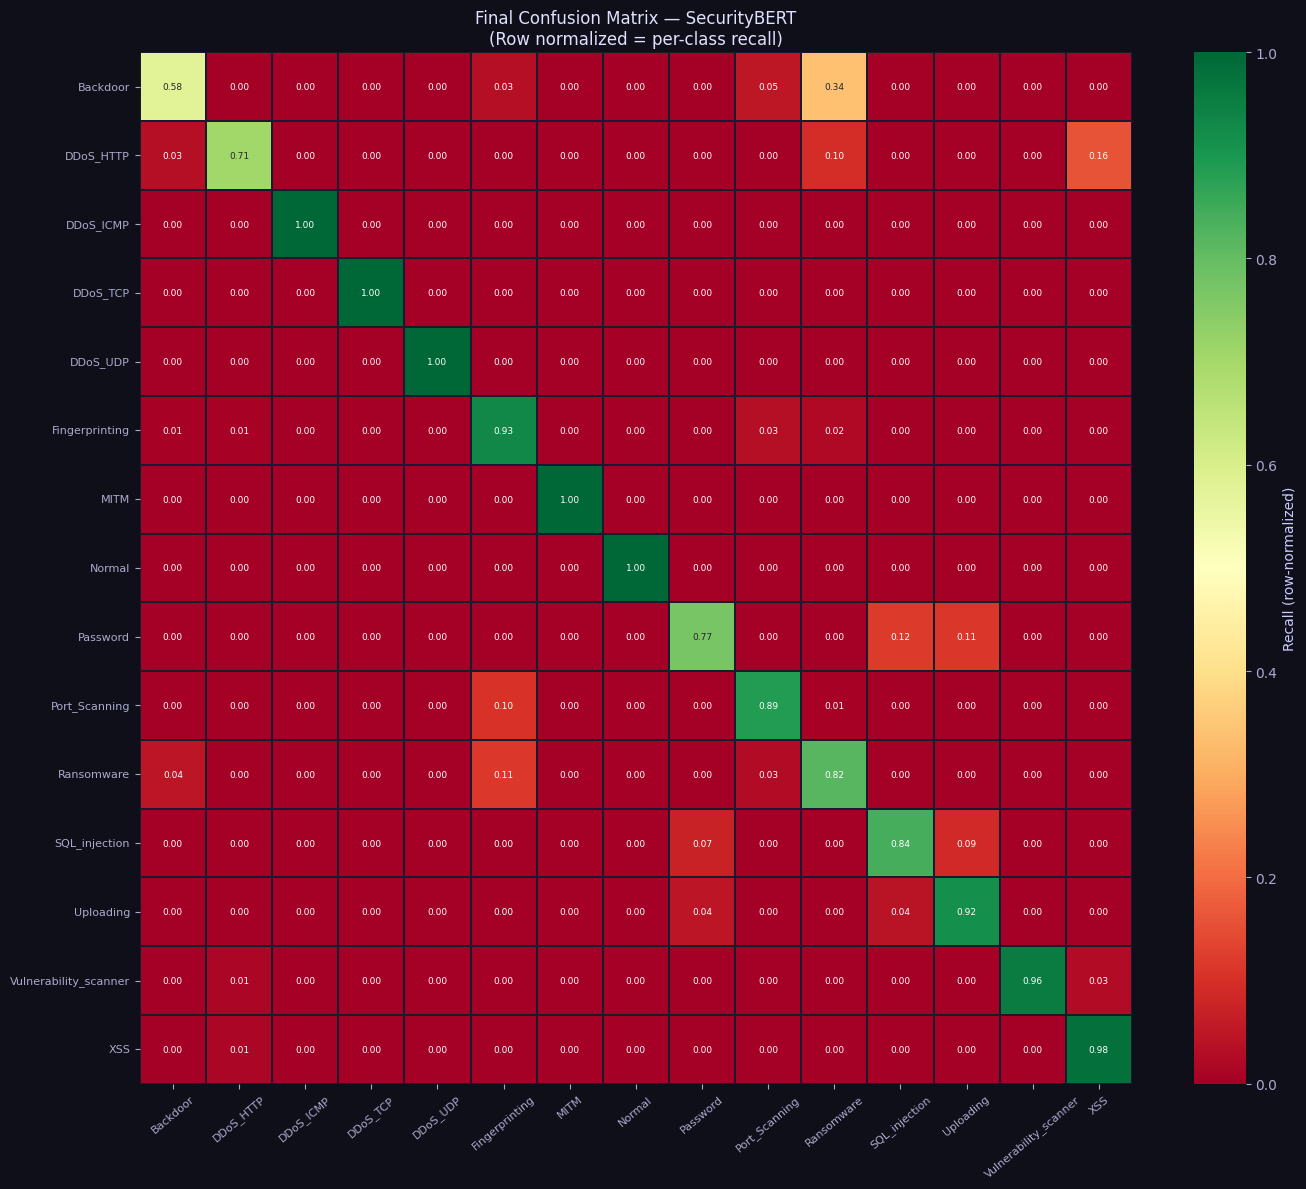

💾 Saved → ..\outputs\figures\N25/nb25_confusion_matrix.png


In [11]:
# ── Confusion matrix ───────────────────────────────────────────────────────────
cm      = confusion_matrix(test_labels_arr, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_norm, ax=ax, cmap='RdYlGn', vmin=0, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size':6.5},
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.3, linecolor='#1a1a2e',
            cbar_kws={'label':'Recall (row-normalized)'})
ax.set_title('Final Confusion Matrix — SecurityBERT\n'
             '(Row normalized = per-class recall)',
             fontsize=12)
ax.tick_params(axis='x', rotation=40, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
fig.savefig(OUT_DIR / 'nb25_confusion_matrix.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUT_DIR}/nb25_confusion_matrix.png')

In [12]:
# ── Save final evaluation report ──────────────────────────────────────────────
report = {
    'week': 25,
    'model': {
        'checkpoint'     : str(BERT_CKPT),
        'parameters'     : sum(p.numel() for p in bert_model.parameters()),
        'size_mb'        : sum(p.numel()*p.element_size()
                               for p in bert_model.parameters()) / 1e6,
    },
    'detection': {
        'accuracy'       : float(accuracy),
        'weighted_f1'    : float(wf1),
        'macro_f1'       : float(mf1),
        'mean_auc'       : float(np.mean(list(auc_scores.values()))),
        'paper_accuracy' : 0.982,
        'matches_paper'  : abs(accuracy - 0.982) < 0.02,
    },
    'healing': {
        'ppo_accuracy'   : float(ppo_acc),
        'target_met'     : ppo_acc >= 0.70,
    },
    'end_to_end': {
        'accuracy'       : float(e2e_acc),
        'mttr_ms'        : float(mttr_ms),
        'pi_est_mttr_ms' : float(mttr_ms * 3),
    },
    'per_class': {
        cls: {
            'precision': float(classification_report(
                test_labels_arr, all_preds,
                target_names=CLASS_NAMES, output_dict=True,
                zero_division=0)[cls]['precision']),
            'recall': float(classification_report(
                test_labels_arr, all_preds,
                target_names=CLASS_NAMES, output_dict=True,
                zero_division=0)[cls]['recall']),
            'f1': float(classification_report(
                test_labels_arr, all_preds,
                target_names=CLASS_NAMES, output_dict=True,
                zero_division=0)[cls]['f1-score']),
            'auc': float(auc_scores.get(cls, 0.0)),
        }
        for cls in CLASS_NAMES
    },
    'baselines': {b[1]: b[2] for b in BASELINES},
}

rep_path = REP_DIR / 'week25_final_report.json'
with open(rep_path, 'w') as f:
    json.dump(report, f, indent=2)

print('=' * 65)
print('  ✅  Week 25 — Final Evaluation Complete')
print('=' * 65)
print(f'\n  📊 Key Results:')
print(f'     BERT Accuracy        : {accuracy*100:.2f}%  (Paper: 98.20%)')
print(f'     Weighted F1          : {wf1:.4f}  (Paper: 0.98)')
print(f'     PPO Healing Accuracy : {ppo_acc*100:.2f}%  (Target: 70%)')
print(f'     End-to-End Accuracy  : {e2e_acc*100:.2f}%')
print(f'     MTTR                 : {mttr_ms:.1f} ms')
print(f'     Pi 3B Est. MTTR      : {mttr_ms*3:.0f} ms')
print(f'\n  📦 {rep_path}')
print(f'  📦 {OUT_DIR}/nb25_final_evaluation.png')
print(f'  📦 {OUT_DIR}/nb25_confusion_matrix.png')
print(f'\n  🔜 Week 26 — Documentation & Thesis Prep')

  ✅  Week 25 — Final Evaluation Complete

  📊 Key Results:
     BERT Accuracy        : 89.24%  (Paper: 98.20%)
     Weighted F1          : 0.8912  (Paper: 0.98)
     PPO Healing Accuracy : 60.89%  (Target: 70%)
     End-to-End Accuracy  : 55.31%
     MTTR                 : 0.7 ms
     Pi 3B Est. MTTR      : 2 ms

  📦 ..\outputs\reports\week25_final_report.json
  📦 ..\outputs\figures\N25/nb25_final_evaluation.png
  📦 ..\outputs\figures\N25/nb25_confusion_matrix.png

  🔜 Week 26 — Documentation & Thesis Prep
